In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 1) EDIT THESE 4 PATHS (one folder per conference)
conference_folders = {
    "Big Ten": r"C:\Users\Dana\OneDrive\Documents\Big 10 Meets",
    "SEC":     r"C:\Users\Dana\OneDrive\Documents\SEC Meets",
    "Big 12":  r"C:\Users\Dana\OneDrive\Documents\Big 12 Meets",
    "ACC":     r"C:\Users\Dana\OneDrive\Documents\ACC Meets",
}

# 2) Column contract (every CSV must have these)
required_cols = [
    "Final Place","Athlete","POINTS",
    "100m","LJ","SP","HJ","400m","110mH","DT","PV","JT","1500m"
]

frames = []

for conf, folder in conference_folders.items():
    folder = str(folder).strip('"')   # handles "Copy as path"
    data_dir = Path(folder)

    files = sorted(data_dir.glob("*.csv"))
    if len(files) == 0:
        raise FileNotFoundError(f"No CSV files found for {conf} in: {data_dir}")

    print(f"{conf}: {len(files)} files")

    for f in files:
        tmp = pd.read_csv(f)

        missing = set(required_cols) - set(tmp.columns)
        if missing:
            raise ValueError(f"{conf} | {f.name} is missing columns: {sorted(missing)}")

        tmp = tmp.copy()
        tmp["conference"] = conf

        # make meet_id unique across conferences (prevents collisions if filenames repeat)
        conf_tag = conf.replace(" ", "").replace("-", "")
        tmp["meet_id"] = f"{conf_tag}_{f.stem}"

        frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
df = df_all  # keep later cells working

print("\nRows:", len(df_all), "| Meets:", df_all["meet_id"].nunique())
print("\nMeets by conference:\n", df_all["conference"].value_counts())

df_all[["conference","meet_id","Final Place","Athlete","POINTS"]].head()

Big Ten: 15 files
SEC: 15 files
Big 12: 15 files
ACC: 15 files

Rows: 451 | Meets: 60

Meets by conference:
 conference
Big Ten    119
Big 12     115
SEC        111
ACC        106
Name: count, dtype: int64


,conference,meet_id,Final Place,Athlete,POINTS
0,Big Ten,BigTen_bigten2010,1,R.J. McGinnis,7381
1,Big Ten,BigTen_bigten2010,2,Frank Shotwell,7379
2,Big Ten,BigTen_bigten2010,3,Dave Grzesiak,7364
3,Big Ten,BigTen_bigten2010,4,Jack Szmanda,7116
4,Big Ten,BigTen_bigten2010,5,Joey Schwecke,7101


In [2]:
event_cols = ["100m","LJ","SP","HJ","400m","110mH","DT","PV","JT","1500m"]

# 1) Real "meets by conference" (your current print is rows)
print("Unique meets by conference:")
print(df.groupby("conference")["meet_id"].nunique())

# 2) Rows per meet (should be <= 8; not necessarily always 8)
rows_per_meet = df.groupby(["conference","meet_id"]).size().rename("n_rows")
print("\nRows per meet distribution:")
print(rows_per_meet.value_counts().sort_index())

# 3) HARD FAIL if *anything* incomplete/missing exists
bad_tokens = {"DNS","DNF","NH","NT","NM","NP","DQ","NA","-","--",""}

bad = []
for col in event_cols:
    s = df[col]
    ss = s.astype(str).str.strip()

    mask = s.isna() | ss.str.upper().isin(bad_tokens)
    if mask.any():
        tmp = df.loc[mask, ["conference","meet_id","Athlete","Final Place", col]].copy()
        tmp = tmp.rename(columns={col: "bad_value"})
        tmp["event"] = col
        bad.append(tmp)

if bad:
    bad_df = pd.concat(bad, ignore_index=True)
    display(bad_df.head(25))
    raise ValueError(f"STOP: Found {len(bad_df)} invalid event marks (DNS/NH/NT/etc or missing). Fix upstream CSVs.")
else:
    print("\nOK: No DNS/NH/NT/etc and no missing marks in event columns.")

df["overall_score"] = -df["Final Place"]   # higher = better overall finish

Unique meets by conference:
conference
ACC        15
Big 12     15
Big Ten    15
SEC        15
Name: meet_id, dtype: int64

Rows per meet distribution:
n_rows
5     2
6     4
7    16
8    37
9     1
Name: count, dtype: int64

OK: No DNS/NH/NT/etc and no missing marks in event columns.


In [3]:
def time_to_seconds_strict(x):
    s = str(x).strip()
    if ":" not in s:
        raise ValueError(f"1500m not in M:SS.ss format: {x}")
    m, sec = s.split(":")
    return int(m) * 60 + float(sec)

df["1500m_sec"] = df["1500m"].apply(time_to_seconds_strict)

print("1500m_sec created. Example rows:")
display(df[["meet_id","Athlete","1500m","1500m_sec"]].head(10))

1500m_sec created. Example rows:


,meet_id,Athlete,1500m,1500m_sec
0,BigTen_bigten2010,R.J. McGinnis,04:35.8,275.8
1,BigTen_bigten2010,Frank Shotwell,04:39.8,279.8
2,BigTen_bigten2010,Dave Grzesiak,04:36.7,276.7
3,BigTen_bigten2010,Jack Szmanda,04:44.7,284.7
4,BigTen_bigten2010,Joey Schwecke,04:54.2,294.2
5,BigTen_bigten2010,Heath Nickles,04:33.4,273.4
6,BigTen_bigten2010,Anya Uzoh,04:49.0,289.0
7,BigTen_bigten2010,Seth Pelock,04:45.2,285.2
8,BigTen_bigten2011,Heath Nickles,04:37.9,277.9
9,BigTen_bigten2011,Brock Spandl,04:49.0,289.0


In [4]:
df_rank = df.copy()

event_cols = ["100m","LJ","SP","HJ","400m","110mH","DT","PV","JT"]
num_cols = [c + "_num" for c in event_cols]

# 1) Make numeric versions of all event marks (extract first number from strings like "7.12", "7.12m", etc.)
for c in event_cols:
    s = df_rank[c].astype(str).str.strip()
    extracted = s.str.extract(r"([0-9]*\.?[0-9]+)")[0]
    df_rank[c + "_num"] = pd.to_numeric(extracted, errors="coerce")

# 2) HARD FAIL if anything didn't parse (should be zero because Cell 2 already validated)
bad_parse = df_rank[df_rank[num_cols].isna().any(axis=1)][
    ["conference","meet_id","Athlete","Final Place"] + event_cols + num_cols
]
if len(bad_parse) > 0:
    display(bad_parse.head(15))
    raise ValueError(f"STOP: {len(bad_parse)} rows have non-numeric event marks after parsing. Fix upstream CSV(s).")

# 3) Rank within each meet (use numeric columns only)
g = df_rank.groupby("meet_id")

# track (lower is better)
df_rank["rank_100m"]  = g["100m_num"].rank(ascending=True, method="min")
df_rank["rank_400m"]  = g["400m_num"].rank(ascending=True, method="min")
df_rank["rank_110H"]  = g["110mH_num"].rank(ascending=True, method="min")
df_rank["rank_1500m"] = g["1500m_sec"].rank(ascending=True, method="min")  # from Cell 3

# field (higher is better)
df_rank["rank_LJ"] = g["LJ_num"].rank(ascending=False, method="min")
df_rank["rank_SP"] = g["SP_num"].rank(ascending=False, method="min")
df_rank["rank_HJ"] = g["HJ_num"].rank(ascending=False, method="min")
df_rank["rank_DT"] = g["DT_num"].rank(ascending=False, method="min")
df_rank["rank_PV"] = g["PV_num"].rank(ascending=False, method="min")
df_rank["rank_JT"] = g["JT_num"].rank(ascending=False, method="min")

display(df_rank[["meet_id","Final Place","Athlete",
         "rank_100m","rank_LJ","rank_SP","rank_HJ","rank_400m","rank_110H",
         "rank_DT","rank_PV","rank_JT","rank_1500m"]].head(10))

,meet_id,Final Place,Athlete,rank_100m,rank_LJ,rank_SP,rank_HJ,rank_400m,rank_110H,rank_DT,rank_PV,rank_JT,rank_1500m
0,BigTen_bigten2010,1,R.J. McGinnis,4.0,2.0,1.0,3.0,5.0,1.0,4.0,7.0,3.0,2.0
1,BigTen_bigten2010,2,Frank Shotwell,3.0,6.0,2.0,3.0,6.0,2.0,1.0,4.0,2.0,4.0
2,BigTen_bigten2010,3,Dave Grzesiak,5.0,5.0,7.0,1.0,2.0,4.0,3.0,3.0,4.0,3.0
3,BigTen_bigten2010,4,Jack Szmanda,5.0,4.0,4.0,3.0,4.0,5.0,6.0,2.0,7.0,5.0
4,BigTen_bigten2010,5,Joey Schwecke,1.0,1.0,5.0,2.0,7.0,8.0,2.0,5.0,5.0,8.0
5,BigTen_bigten2010,6,Heath Nickles,8.0,8.0,6.0,8.0,3.0,6.0,8.0,1.0,1.0,1.0
6,BigTen_bigten2010,7,Anya Uzoh,2.0,2.0,8.0,3.0,1.0,7.0,7.0,5.0,6.0,7.0
7,BigTen_bigten2010,8,Seth Pelock,7.0,7.0,3.0,7.0,8.0,3.0,5.0,7.0,8.0,6.0
8,BigTen_bigten2011,1,Heath Nickles,8.0,6.0,5.0,7.0,3.0,3.0,5.0,2.0,1.0,2.0
9,BigTen_bigten2011,2,Brock Spandl,2.0,3.0,7.0,2.0,4.0,2.0,3.0,1.0,6.0,7.0


In [5]:
rank_cols = [c for c in df_rank.columns if c.startswith("rank_")]

spearman_rank = (
    (-df_rank[rank_cols])  # flip so higher = better
    .corrwith(df_rank["overall_score"], method="spearman")
    .rename("spearman_rho")
    .reset_index()
    .rename(columns={"index": "event"})
)

spearman_rank["event"] = spearman_rank["event"].str.replace("^rank_", "", regex=True)
spearman_rank = spearman_rank.sort_values("spearman_rho", ascending=False)

spearman_rank


,event,spearman_rho
7,DT,0.573294
5,SP,0.550651
9,JT,0.477129
2,110H,0.469527
4,LJ,0.447131
1,400m,0.439881
0,100m,0.409977
8,PV,0.407222
6,HJ,0.299780
3,1500m,0.202685


In [6]:
df_z = df_rank.copy()  # reuse *_num columns created in Cell 4

# make sure the numeric columns exist
needed = ["100m_num","400m_num","110mH_num","1500m_sec",
          "LJ_num","SP_num","HJ_num","DT_num","PV_num","JT_num"]
missing = [c for c in needed if c not in df_z.columns]
if missing:
    raise ValueError(f"Missing required numeric columns: {missing}. Run Cell 4 first.")

def z_within(s):
    sd = s.std(ddof=0)
    if sd == 0:
        return s*0.0  # all equal -> everyone gets z = 0
    return (s - s.mean()) / sd

g = df_z.groupby("meet_id")

# track: lower time is better -> flip sign first so higher = better
df_z["z_100m"]  = g["100m_num"].transform(lambda s: z_within(-s))
df_z["z_400m"]  = g["400m_num"].transform(lambda s: z_within(-s))
df_z["z_110H"]  = g["110mH_num"].transform(lambda s: z_within(-s))
df_z["z_1500m"] = g["1500m_sec"].transform(lambda s: z_within(-s))

# field: higher mark is better
df_z["z_LJ"] = g["LJ_num"].transform(z_within)
df_z["z_SP"] = g["SP_num"].transform(z_within)
df_z["z_HJ"] = g["HJ_num"].transform(z_within)
df_z["z_DT"] = g["DT_num"].transform(z_within)
df_z["z_PV"] = g["PV_num"].transform(z_within)
df_z["z_JT"] = g["JT_num"].transform(z_within)

z_cols = [c for c in df_z.columns if c.startswith("z_")]

print("Z-score columns:", z_cols)
display(df_z[["meet_id","Final Place","Athlete"] + z_cols].head())

Z-score columns: ['z_100m', 'z_400m', 'z_110H', 'z_1500m', 'z_LJ', 'z_SP', 'z_HJ', 'z_DT', 'z_PV', 'z_JT']


,meet_id,Final Place,Athlete,z_100m,z_400m,z_110H,z_1500m,z_LJ,z_SP,z_HJ,z_DT,z_PV,z_JT
0,BigTen_bigten2010,1,R.J. McGinnis,0.118952,-0.289184,1.443446,0.976796,1.026870,1.883898,0.130189,0.091381,-1.044074,0.949044
1,BigTen_bigten2010,2,Frank Shotwell,0.436157,-0.619679,0.867176,0.380279,-0.256718,0.711140,0.130189,1.929989,-0.284747,1.009918
2,BigTen_bigten2010,3,Dave Grzesiak,-0.424829,1.004060,0.335234,0.842580,-0.128359,-0.548950,1.692456,0.455338,0.854242,0.144153
3,BigTen_bigten2010,4,Jack Szmanda,-0.424829,0.371808,-0.196708,-0.350454,-0.085573,0.024952,0.130189,-0.746346,1.233905,-1.022600
4,BigTen_bigten2010,5,Joey Schwecke,1.795609,-1.208824,-1.726040,-1.767181,1.155229,-0.162190,0.650945,0.678104,-0.664411,-0.261674


In [7]:
pearson_z = (
    df_z[z_cols]
    .corrwith(df_z["overall_score"], method="pearson")
    .rename("pearson_r")
    .reset_index()
    .rename(columns={"index": "event"})
)

pearson_z["event"] = pearson_z["event"].str.replace("^z_", "", regex=True)
pearson_z = pearson_z.sort_values("pearson_r", ascending=False)

pearson_z

,event,pearson_r
7,DT,0.584866
5,SP,0.566954
4,LJ,0.491580
9,JT,0.482498
2,110H,0.477791
1,400m,0.459468
8,PV,0.427051
0,100m,0.417747
6,HJ,0.304808
3,1500m,0.233309


In [8]:
# RQ3 cross-check: Spearman by conference using ranks (uniform "higher is better")
rank_cols = [c for c in df_rank.columns if c.startswith("rank_")]

corr_list = []
for conf, d in df_rank.groupby("conference"):
    s = (-d[rank_cols]).corrwith(d["overall_score"], method="spearman")
    s.name = conf
    corr_list.append(s)

rank_wide = pd.concat(corr_list, axis=1)
rank_wide.index = rank_wide.index.str.replace("^rank_", "", regex=True)
rank_wide["mean_rho"]  = rank_wide.mean(axis=1)
rank_wide["range_rho"] = rank_wide.max(axis=1) - rank_wide.min(axis=1)

display(rank_wide.sort_values("mean_rho", ascending=False))
display(rank_wide.sort_values("range_rho", ascending=False).head(10))

,ACC,Big 12,Big Ten,SEC,mean_rho,range_rho
DT,0.537147,0.583162,0.492740,0.693160,0.576552,0.200419
SP,0.489182,0.581609,0.465661,0.670850,0.551825,0.205189
JT,0.574839,0.473072,0.279346,0.613020,0.485069,0.333674
110H,0.432624,0.519106,0.474198,0.442737,0.467166,0.086482
LJ,0.427937,0.474695,0.314200,0.577882,0.448679,0.263682
400m,0.575528,0.401604,0.480866,0.303699,0.440424,0.271829
PV,0.534888,0.366079,0.232109,0.527056,0.415033,0.302779
100m,0.419746,0.362107,0.419989,0.433684,0.408881,0.071577
HJ,0.252161,0.340212,0.241100,0.358560,0.298008,0.117460
1500m,0.456458,0.126332,0.116467,0.136089,0.208836,0.339991


,ACC,Big 12,Big Ten,SEC,mean_rho,range_rho
1500m,0.456458,0.126332,0.116467,0.136089,0.208836,0.339991
JT,0.574839,0.473072,0.279346,0.613020,0.485069,0.333674
PV,0.534888,0.366079,0.232109,0.527056,0.415033,0.302779
400m,0.575528,0.401604,0.480866,0.303699,0.440424,0.271829
LJ,0.427937,0.474695,0.314200,0.577882,0.448679,0.263682
SP,0.489182,0.581609,0.465661,0.670850,0.551825,0.205189
DT,0.537147,0.583162,0.492740,0.693160,0.576552,0.200419
HJ,0.252161,0.340212,0.241100,0.358560,0.298008,0.117460
110H,0.432624,0.519106,0.474198,0.442737,0.467166,0.086482
100m,0.419746,0.362107,0.419989,0.433684,0.408881,0.071577


In [9]:
# sample sizes
conf_sizes = (
    df_z.groupby("conference")
        .agg(n_rows=("overall_score", "size"),
             n_meets=("meet_id", "nunique"))
)
display(conf_sizes)

# correlations by conference -> wide table
corr_list = []
for conf, d in df_z.groupby("conference"):
    s = d[z_cols].corrwith(d["overall_score"], method="pearson")
    s.name = conf
    corr_list.append(s)

z_wide = pd.concat(corr_list, axis=1)
z_wide.index = z_wide.index.str.replace("^z_", "", regex=True)

# summary columns for RQ3
z_wide["mean_r"]  = z_wide.mean(axis=1)
z_wide["range_r"] = z_wide.max(axis=1) - z_wide.min(axis=1)

# show: strongest overall + most conference-different
display(z_wide.sort_values("mean_r", ascending=False))
display(z_wide.sort_values("range_r", ascending=False).head(10))

,n_rows,n_meets
conference,,
ACC,106,15
Big 12,115,15
Big Ten,119,15
SEC,111,15


,ACC,Big 12,Big Ten,SEC,mean_r,range_r
DT,0.546718,0.579498,0.548105,0.670323,0.586161,0.123605
SP,0.518413,0.590558,0.516473,0.646430,0.567969,0.129957
LJ,0.458374,0.516571,0.375950,0.626480,0.494344,0.250530
JT,0.571711,0.467665,0.357747,0.553543,0.487666,0.213964
110H,0.393125,0.534844,0.477414,0.500220,0.476401,0.141719
400m,0.587462,0.434037,0.499374,0.323239,0.461028,0.264224
PV,0.553422,0.377240,0.276442,0.528324,0.433857,0.276980
100m,0.421979,0.407744,0.435241,0.407191,0.418039,0.028050
HJ,0.237928,0.384461,0.215863,0.383047,0.305325,0.168599
1500m,0.466971,0.227503,0.106658,0.158294,0.239857,0.360312


,ACC,Big 12,Big Ten,SEC,mean_r,range_r
1500m,0.466971,0.227503,0.106658,0.158294,0.239857,0.360312
PV,0.553422,0.377240,0.276442,0.528324,0.433857,0.276980
400m,0.587462,0.434037,0.499374,0.323239,0.461028,0.264224
LJ,0.458374,0.516571,0.375950,0.626480,0.494344,0.250530
JT,0.571711,0.467665,0.357747,0.553543,0.487666,0.213964
HJ,0.237928,0.384461,0.215863,0.383047,0.305325,0.168599
110H,0.393125,0.534844,0.477414,0.500220,0.476401,0.141719
SP,0.518413,0.590558,0.516473,0.646430,0.567969,0.129957
DT,0.546718,0.579498,0.548105,0.670323,0.586161,0.123605
100m,0.421979,0.407744,0.435241,0.407191,0.418039,0.028050


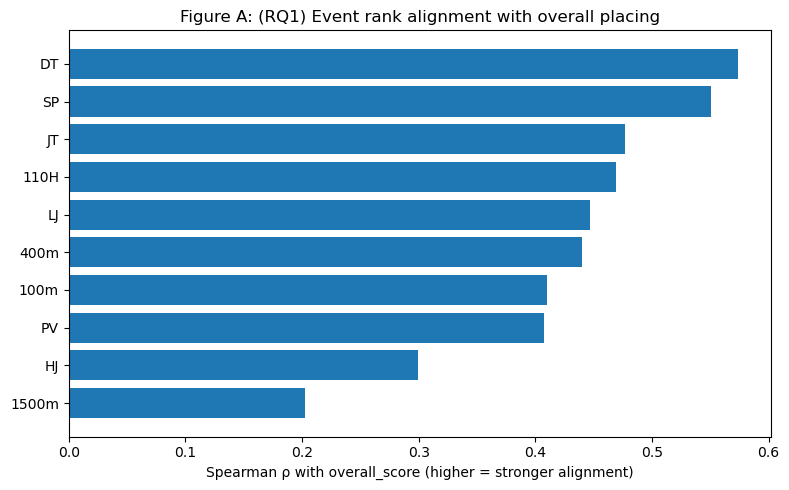

In [10]:
plot_df = spearman_rank.copy().sort_values("spearman_rho", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["event"], plot_df["spearman_rho"])
plt.xlabel("Spearman ρ with overall_score (higher = stronger alignment)")
plt.title("Figure A: (RQ1) Event rank alignment with overall placing")
plt.tight_layout()
plt.show()


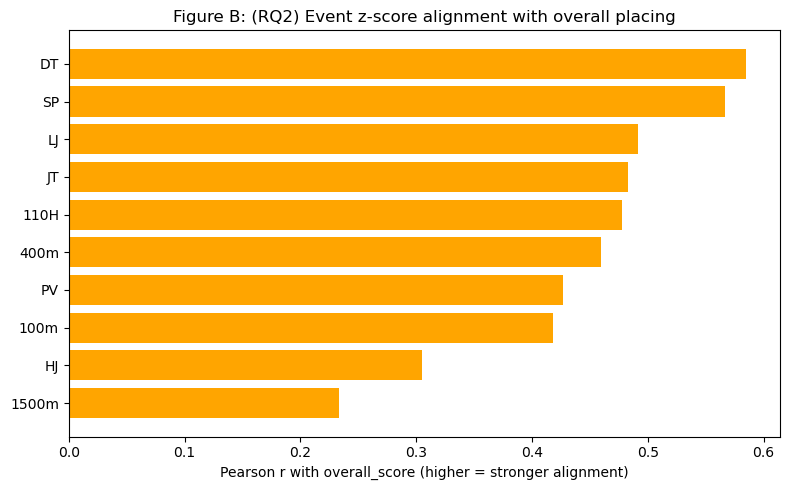

In [11]:
plot_df = pearson_z.copy().sort_values("pearson_r", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["event"], plot_df["pearson_r"], color="orange")
plt.xlabel("Pearson r with overall_score (higher = stronger alignment)")
plt.title("Figure B: (RQ2) Event z-score alignment with overall placing")
plt.tight_layout()
plt.show()


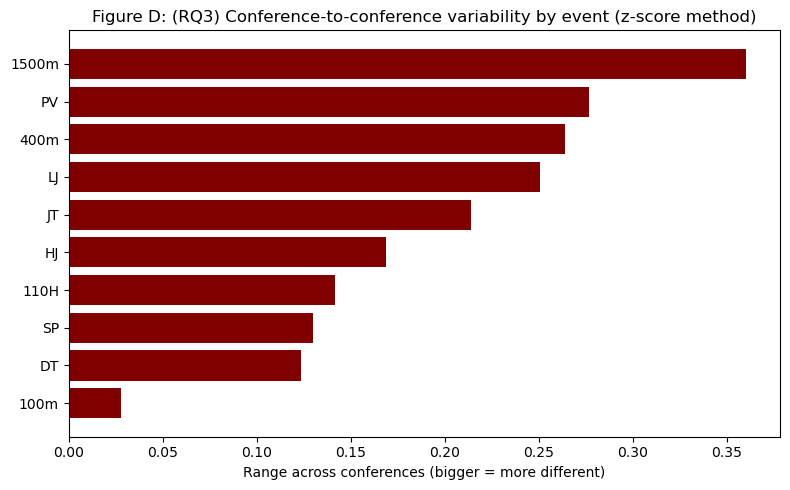

In [17]:
plot_df = z_wide["range_r"].sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df.index, plot_df.values, color="maroon")
plt.xlabel("Range across conferences (bigger = more different)")
plt.title("Figure D: (RQ3) Conference-to-conference variability by event (z-score method)")
plt.tight_layout()
plt.show()


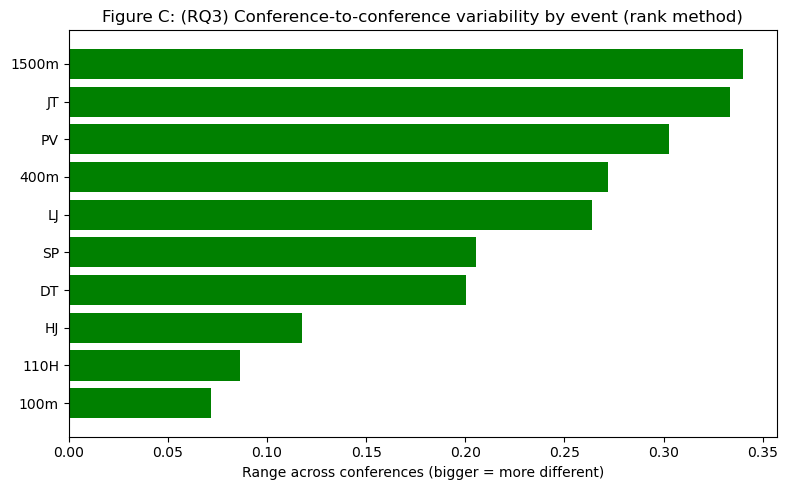

In [18]:
plot_df = rank_wide["range_rho"].sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df.index, plot_df.values, color='green')
plt.xlabel("Range across conferences (bigger = more different)")
plt.title("Figure C: (RQ3) Conference-to-conference variability by event (rank method)")
plt.tight_layout()
plt.show()

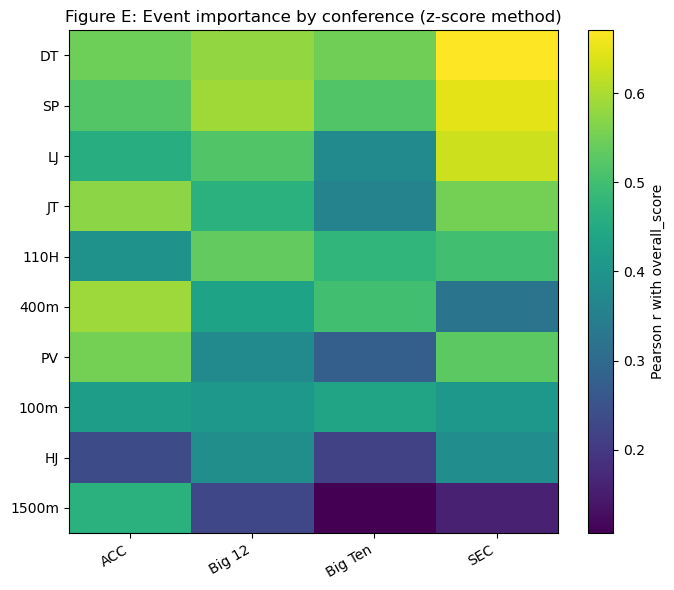

In [19]:
confs = ["ACC", "Big 12", "Big Ten", "SEC"]

M = z_wide[confs].copy()
M = M.loc[M.mean(axis=1).sort_values(ascending=False).index]  # order events by overall strength

plt.figure(figsize=(7, 6))
img = plt.imshow(M.values, aspect="auto")
plt.colorbar(img, label="Pearson r with overall_score")

plt.xticks(range(len(confs)), confs, rotation=30, ha="right")
plt.yticks(range(len(M.index)), M.index)
plt.title("Figure E: Event importance by conference (z-score method)")
plt.tight_layout()
plt.show()

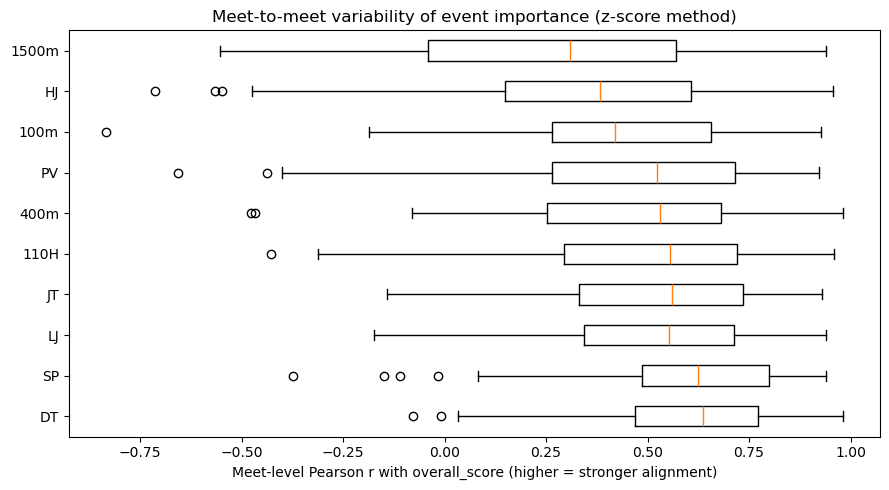

In [15]:
# Build meet-level correlations: for each meet_id, correlate each z_* with overall_score
meet_corrs = []
for mid, d in df_z.groupby("meet_id"):
    row = {"meet_id": mid, "conference": d["conference"].iloc[0]}
    for ev in z_cols:
        row[ev.replace("z_", "")] = d[ev].corr(d["overall_score"], method="pearson")
    meet_corrs.append(row)

meet_corrs = pd.DataFrame(meet_corrs)

# Order events by average meet-level correlation
events = [c for c in meet_corrs.columns if c not in ["meet_id","conference"]]
order = meet_corrs[events].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(9, 5))
plt.boxplot([meet_corrs[e].dropna() for e in order], tick_labels=order, vert=False)
plt.xlabel("Meet-level Pearson r with overall_score (higher = stronger alignment)")
plt.title("Meet-to-meet variability of event importance (z-score method)")
plt.tight_layout()
plt.show()